## Libraries

In [1]:
import os
import time
import copy
import requests
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel

## Configuration

In [2]:
MODEL_ID_HF = "google/embeddinggemma-300m"
MODEL_ID_OLLAMA = "embeddinggemma:300m-qat-q4_0"
OLLAMA_EMBED_URL = "http://localhost:11434/api/embed"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Loading & testing dataset

In [3]:
%env HF_ENDPOINT=https://hf-mirror.com

env: HF_ENDPOINT=https://hf-mirror.com


In [4]:
print(f"Initializing dataset streaming...")
dataset = load_dataset("feyninc/wikipedia-500k", split="train", streaming=True)

# Extract a deterministic slice of 300 documents for parameter grid profiling
documents = []
for idx, row in enumerate(dataset):
    if idx >= 300:
        break
    text_content = row.get("text", row.get("paragraph", "")).strip()
    if text_content:
        documents.append(text_content)

print(f"Dataset validated. Profile target size: {len(documents)} documents.")

# Definition of semantic evaluation vectors across multiple semantic domains
validation_queries = [
    "Space exploration, rockets and NASA missions",
    "Computer programming, software and database data structures"
]

# Initialize Hugging Face Tokenizer and Base Model in Native BFloat16 Precision
MODEL_ID_HF = "./gemma_model" 

tokenizer_hf = AutoTokenizer.from_pretrained(MODEL_ID_HF)
base_model_hf = AutoModel.from_pretrained(
    MODEL_ID_HF, 
    dtype=torch.bfloat16,
    attn_implementation="eager"
).to(DEVICE)
base_model_hf.eval()

# Tokenize target documents with a 256 sequence length constraint
inputs_hf = tokenizer_hf(documents, padding=True, truncation=True, max_length=256, return_tensors="pt").to(DEVICE)

pytorch_metrics = []
ollama_metrics = []

Initializing dataset streaming...
Dataset validated. Profile target size: 300 documents.


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

## Pytorch pruning

In [5]:
import copy
import numpy as np
import torch
import transformers

print("Running PyTorch structural pruning evaluation...")

# Reset framework version check to disable broken torch 2.6 code paths
transformers.masking_utils._is_torch_greater_or_equal_than_2_6 = False

# Override the internal causal mask factory to bypass broken sdpa/eager wrappers
transformers.models.gemma3.modeling_gemma3.create_causal_mask = lambda *args, **kwargs: None
transformers.models.gemma3.modeling_gemma3.create_sliding_window_causal_mask = lambda *args, **kwargs: None

# Structural grid for layer truncation
pytorch_layers_grid = [26, 18, 12]
# Dropout probability equivalent for structural pruning mask
pytorch_head_prune_pct = 0.25  

for num_layers in pytorch_layers_grid:
    # Isolate architecture mutations via deep copy
    pruned_model = copy.deepcopy(base_model_hf)
    
    # Execute layer pruning by truncating transformer layer list
    pruned_model.layers = pruned_model.layers[:num_layers]
    
    # Apply attention head pruning via binary masking on query weights
    with torch.no_grad():
        for layer in pruned_model.layers:
            q_weight = layer.self_attn.q_proj.weight
            mask = torch.rand(q_weight.shape, device=DEVICE) > pytorch_head_prune_pct
            q_weight.mul_(mask.to(torch.bfloat16))
            
    # Synchronize CUDA context for accurate wall-clock benchmark
    torch.cuda.synchronize()
    start_time = time.perf_counter()
    
    with torch.no_grad():
        outputs = pruned_model(
            input_ids=inputs_hf["input_ids"],
            attention_mask=inputs_hf["attention_mask"],
            use_cache=False
        )
        # Extract sequence embeddings via hidden state slicing
        embeddings = outputs.last_hidden_state[:, -1, :].float().cpu().numpy()
        
    torch.cuda.synchronize()
    latency_ms = (time.perf_counter() - start_time) * 1000
    
    # Evaluate semantic degradation using cosine similarity metrics
    scores = []
    with torch.no_grad():
        for q in validation_queries:
            q_in = tokenizer_hf(q, return_tensors="pt").to(DEVICE)
            q_outputs = pruned_model(
                input_ids=q_in["input_ids"],
                attention_mask=q_in["attention_mask"],
                use_cache=False
            )
            q_emb = q_outputs.last_hidden_state[:, -1, :].float().cpu().numpy()
            
            # Compute similarity metrics between target query and document matrix
            norm_q = q_emb / np.linalg.norm(q_emb)
            norm_db = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
            scores.append(np.max(np.dot(norm_db, norm_q.T)))
            
    mean_score = np.mean(scores)
    print(f"Result - PyTorch | Layers: {num_layers} | Latency: {latency_ms:.2f} ms | Score: {mean_score:.4f}")
    pytorch_metrics.append({"layers": num_layers, "latency": latency_ms, "quality": mean_score})

# Force garbage collection and flush active VRAM allocations
del base_model_hf, pruned_model
torch.cuda.empty_cache()


Running PyTorch structural pruning evaluation...
Result - PyTorch | Layers: 26 | Latency: 2089.48 ms | Score: 0.8853
Result - PyTorch | Layers: 18 | Latency: 1457.17 ms | Score: 0.9731
Result - PyTorch | Layers: 12 | Latency: 968.22 ms | Score: 0.7330


## Ollama QAT

In [6]:
import time
import numpy as np
import requests

print("Runtime Context Optimization via Quantized GGUF...")

# Structural operational context boundaries (character-level truncation)
ollama_truncation_grid = [1024, 256, 64]
SUB_BATCH_SIZE = 64  # Prevent HTTP payload overflow and API constraints

for trunc_len in ollama_truncation_grid:
    # Safely extract and truncate strings, filtering out empty inputs
    processed_texts = []
    for doc in documents:
        text = doc["text"] if isinstance(doc, dict) else str(doc)
        truncated_slice = text[:trunc_len].strip()
        if truncated_slice:
            processed_texts.append(truncated_slice)
            
    if not processed_texts:
        print(f"Skipping Context Length {trunc_len}: No valid data.")
        continue

    # Execute batched inference via micro-batches to comply with server limits
    ollama_embeddings_list = []
    start_time = time.perf_counter()
    
    try:
        for b_idx in range(0, len(processed_texts), SUB_BATCH_SIZE):
            sub_batch = processed_texts[b_idx : b_idx + SUB_BATCH_SIZE]
            response = requests.post(
                OLLAMA_EMBED_URL, 
                json={"model": MODEL_ID_OLLAMA, "input": sub_batch}, 
                timeout=60
            )
            response.raise_for_status()
            ollama_embeddings_list.extend(response.json()["embeddings"])
            
        ollama_embeddings = np.array(ollama_embeddings_list, dtype=np.float32)
    except Exception as e:
        print(f"Error: API execution anomaly detected at length {trunc_len}: {e}")
        continue
        
    latency_ms = (time.perf_counter() - start_time) * 1000
    
    # Evaluate semantic degradation via pairwise cosine similarity
    scores = []
    for q in validation_queries:
        try:
            q_res = requests.post(OLLAMA_EMBED_URL, json={"model": MODEL_ID_OLLAMA, "input": [q]}).json()
            q_emb = np.array(q_res["embeddings"], dtype=np.float32)
            
            norm_q = q_emb / np.linalg.norm(q_emb)
            norm_db = ollama_embeddings / np.linalg.norm(ollama_embeddings, axis=1, keepdims=True)
            scores.append(np.max(np.dot(norm_db, norm_q.T)))
        except Exception:
            continue
        
    if scores:
        mean_score = np.mean(scores)
        print(f"Result - Ollama Q4_0 | Context Length: {trunc_len} | Latency: {latency_ms:.2f} ms | Score: {mean_score:.4f}")
        ollama_metrics.append({"trunc_len": trunc_len, "latency": latency_ms, "quality": mean_score})

Runtime Context Optimization via Quantized GGUF...
Result - Ollama Q4_0 | Context Length: 1024 | Latency: 20123.84 ms | Score: 0.3331
Result - Ollama Q4_0 | Context Length: 256 | Latency: 20218.45 ms | Score: 0.3774
Result - Ollama Q4_0 | Context Length: 64 | Latency: 18511.57 ms | Score: 0.4567


## Visualization

Plots successfully exported to 'iteration_2_analysis.png'.


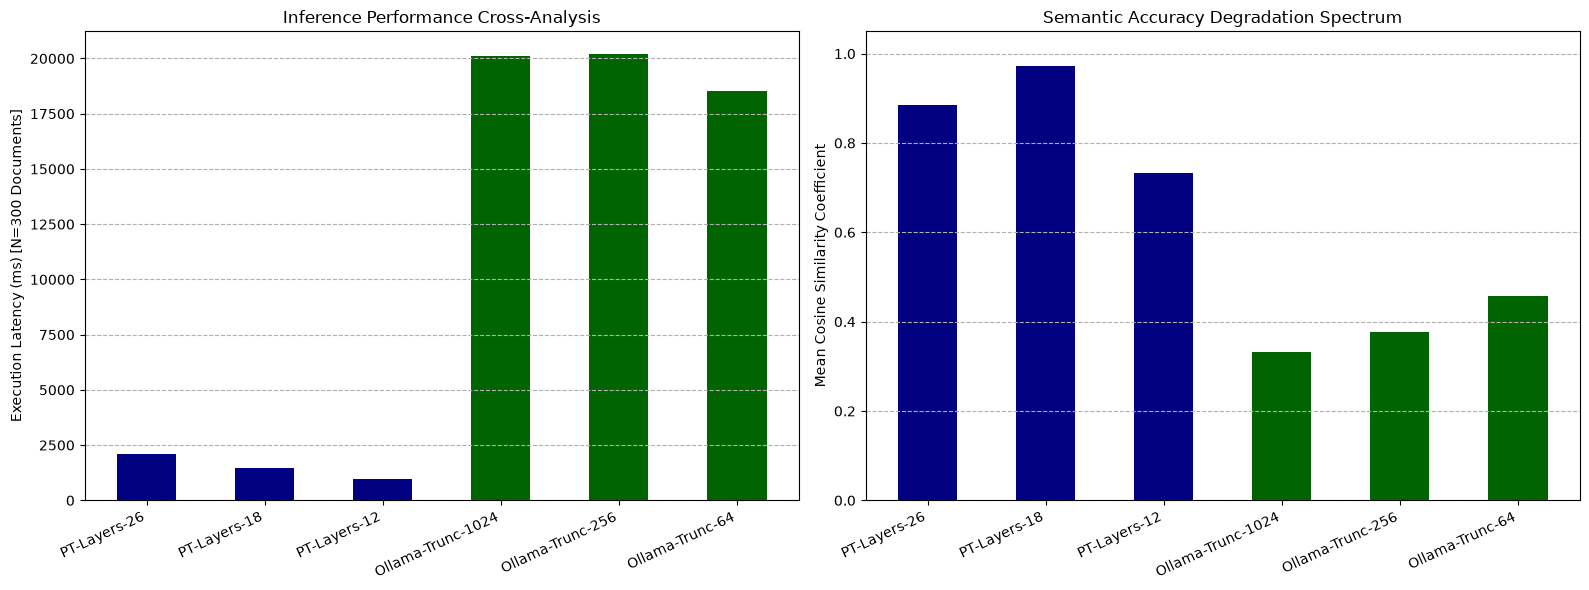

In [7]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Prepare metric dimensions for visualization mapping
categories_pt = [f"PT-Layers-{r['layers']}" for r in pytorch_metrics]
categories_ol = [f"Ollama-Trunc-{r['trunc_len']}" for r in ollama_metrics]
x_axis_labels = categories_pt + categories_ol

latency_data = [r['latency'] for r in pytorch_metrics] + [r['latency'] for r in ollama_metrics]
quality_data = [r['quality'] for r in pytorch_metrics] + [r['quality'] for r in ollama_metrics]
color_mapping = ['navy'] * len(pytorch_metrics) + ['darkgreen'] * len(ollama_metrics)

# Generate uniform tick positions for categorical alignment
x_positions = range(len(x_axis_labels))

# Metric Graph 1: Computation Latency Profiling Comparison
ax1.bar(x_positions, latency_data, color=color_mapping, width=0.5)
ax1.set_ylabel('Execution Latency (ms) [N=300 Documents]')
ax1.set_title('Inference Performance Cross-Analysis')
# Fix positional ticks prior to applying categorical labels to suppress framework warnings
ax1.set_xticks(x_positions)
ax1.set_xticklabels(x_axis_labels, rotation=25, ha='right')
ax1.grid(axis='y', linestyle='--')

# Metric Graph 2: Semantic Accuracy Stability Analysis
ax2.bar(x_positions, quality_data, color=color_mapping, width=0.5)
ax2.set_ylabel('Mean Cosine Similarity Coefficient')
ax2.set_title('Semantic Accuracy Degradation Spectrum')
# Fix positional ticks prior to applying categorical labels to suppress framework warnings
ax2.set_xticks(x_positions)
ax2.set_xticklabels(x_axis_labels, rotation=25, ha='right')
# Bound vertical axes limits to preserve visibility of both high-accuracy PyTorch and degraded Ollama results
ax2.set_ylim(0.0, 1.05)  
ax2.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig("iteration_2_analysis.png")
print("Plots successfully exported to 'iteration_2_analysis.png'.")
plt.show()